In [55]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from tqdm.auto import tqdm
from cs336_basics.model import TransformerLM, get_validation_loss

In [89]:
model_names = ['init-swiglu-ones', 'init-swiglu-normal']
models = {}
for model_name in model_names:
  save_init = torch.load(f"./{model_name}.pt", map_location=torch.device('cpu'))
  save_end = torch.load(f"./{model_name}.step1000.pt", map_location=torch.device('cpu'))
  init_model_dict = save_init['model']
  end_model_dict = save_end['model']
  end_model_dict = {k.lstrip('_orig_mod.'): v for k, v in end_model_dict.items()}
  training_loss = save_end['training_loss']
  models[model_name] = {
    'init_model_dict': init_model_dict,
    'end_model_dict': end_model_dict,
    'training_loss': training_loss,
  }
# models

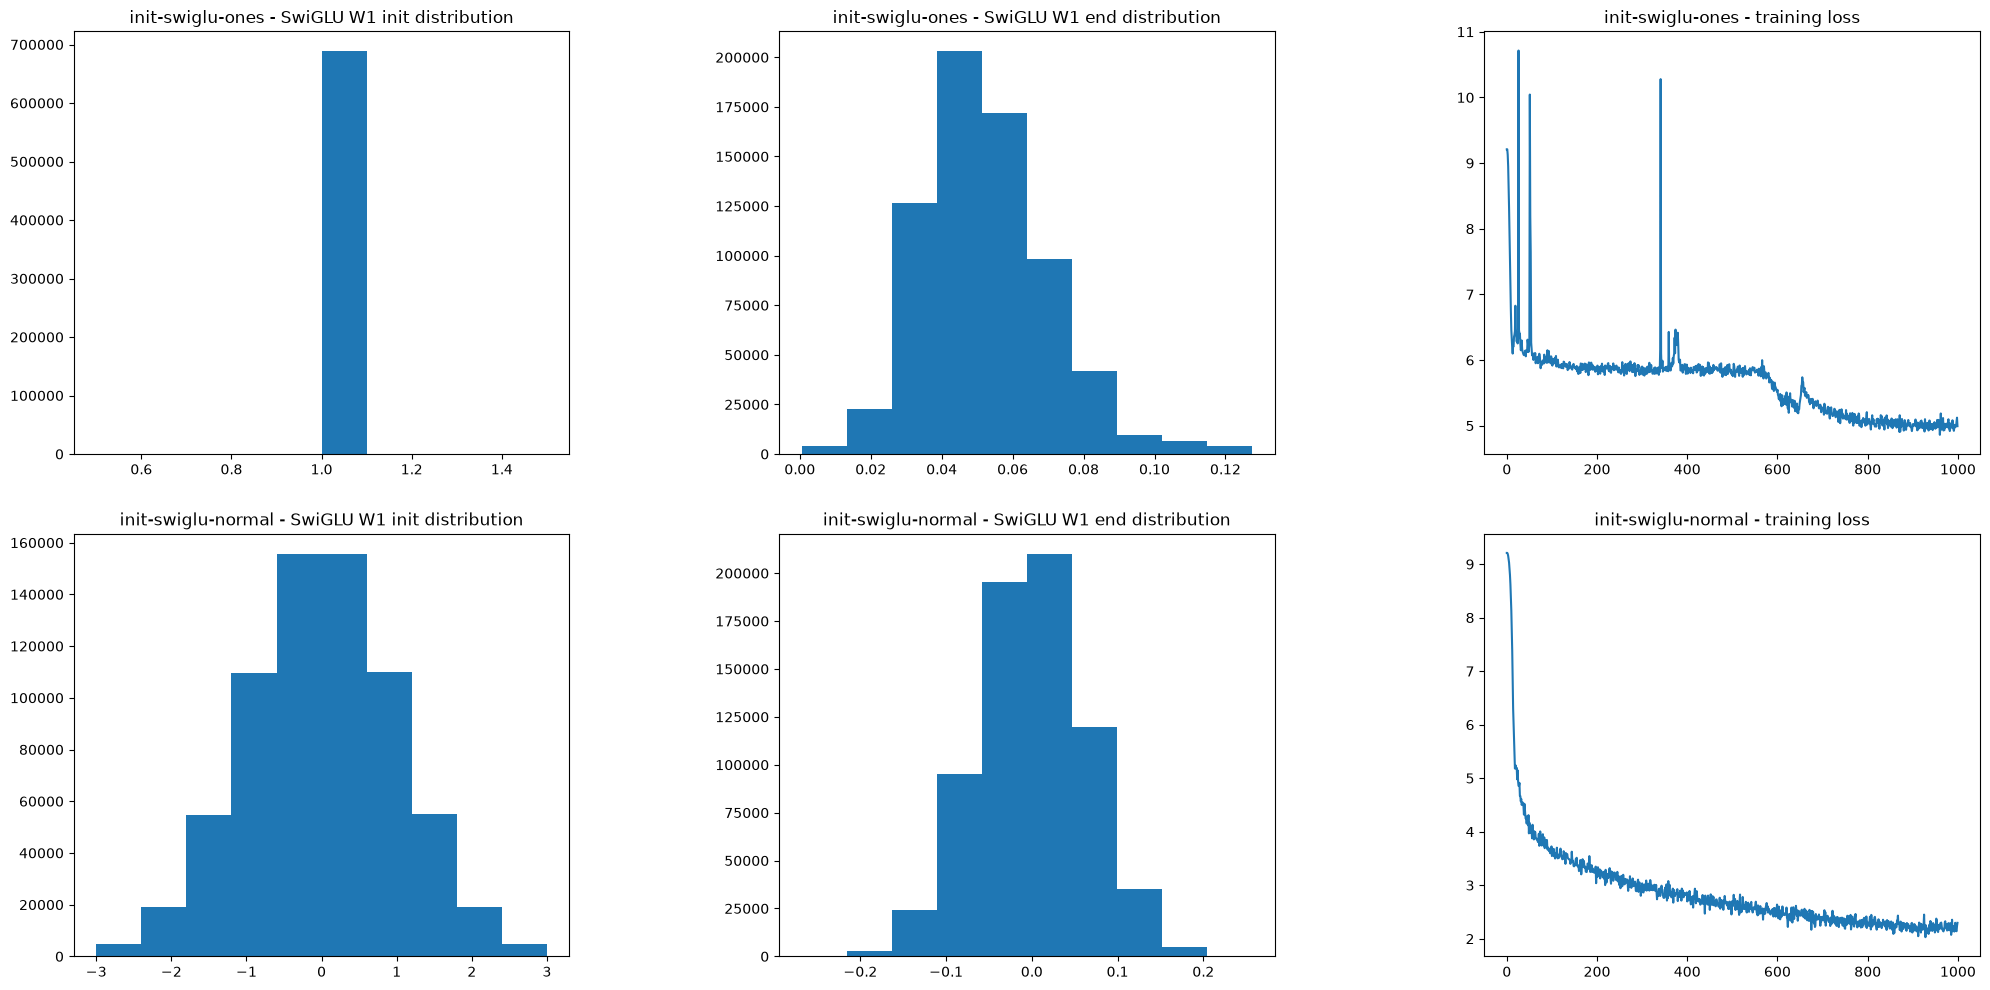

In [94]:
fig, grid = plt.subplots(2, 3, figsize=(20, 10))

for i, (name, info) in enumerate(models.items()):
  grid[i, 0].set_title(f'{name} - SwiGLU W1 init distribution')
  grid[i, 0].hist(info['init_model_dict']['layers.0.ff_block.ffn.w1'].reshape(-1))

  grid[i, 1].set_title(f'{name} - SwiGLU W1 end distribution')
  grid[i, 1].hist(info['end_model_dict']['layers.0.ff_block.ffn.w1'].reshape(-1))

  grid[i, 2].set_title(f'{name} - training loss')
  grid[i, 2].plot(info['training_loss'])

fig.tight_layout(h_pad=2.5, w_pad=10.5)
